# AR Library Navigator Results Analysis
**Dissertation Christian Wright | MCAST 2026**

Analyses post-test survey responses (n=12) and application session logs (n=15 hunt, 15 book search).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, csv, os
from datetime import datetime

OUT = r'C:\Users\chrwr\Documents\mcast\3rd year\Dissertation\Results\charts'
os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({'font.family':'Arial','font.size':11,'axes.titlesize':13,'axes.titleweight':'bold','figure.dpi':150})
BLUE='#2E75B6'; GREEN='#70AD47'; ORANGE='#ED7D31'; RED='#C00000'; GREY='#A9A9A9'
print('Setup complete.')

Setup complete.


## 1. Load Survey Data

In [2]:
survey_path = r'C:\Users\chrwr\Documents\mcast\3rd year\Dissertation\Results\AR Library Navigator Student Feedback(1-12).xlsx'
df = pd.read_excel(survey_path)
col_map = {
    df.columns[6]:'Q1_first_visit', df.columns[7]:'Q2_pre_conf', df.columns[8]:'Q3_ar_before',
    df.columns[9]:'Q4_engaging', df.columns[10]:'Q6_confident_after', df.columns[11]:'Q5_motivated',
    df.columns[12]:'Q7_recommend', df.columns[13]:'Q8_aware', df.columns[14]:'Q9_vs_tour',
    df.columns[18]:'Q13_clue_clarity', df.columns[19]:'Q14_clue_fun',
    df.columns[20]:'Q15_understood', df.columns[21]:'Q16_enough_info',
    df.columns[25]:'Q20_prev_orientation',
    df.columns[29]:'Q29_dropdown', df.columns[30]:'Q30_directions',
    df.columns[31]:'Q31_found_shelf', df.columns[32]:'Q32_use_again',
    df.columns[33]:'Q33_find_book', df.columns[37]:'Q26_overall', df.columns[38]:'Q27_more_prepared',
}
df.rename(columns=col_map, inplace=True)
print(f'Loaded {len(df)} responses.')
df[['Q2_pre_conf','Q4_engaging','Q6_confident_after','Q7_recommend','Q8_aware','Q9_vs_tour','Q26_overall']].describe().round(2)

Loaded 12 responses.


,Q2_pre_conf,Q4_engaging,Q6_confident_after,Q7_recommend,Q8_aware,Q9_vs_tour,Q26_overall
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00
mean,2.42,3.83,3.92,4.58,4.50,4.33,4.25
std,0.90,0.72,0.79,0.67,0.67,0.78,0.62
min,1.00,3.00,3.00,3.00,3.00,3.00,3.00
25%,2.00,3.00,3.00,4.00,4.00,4.00,4.00
50%,2.50,4.00,4.00,5.00,5.00,4.50,4.00
75%,3.00,4.00,4.25,5.00,5.00,5.00,5.00
max,4.00,5.00,5.00,5.00,5.00,5.00,5.00


## 2. Figure 1 Participant Background

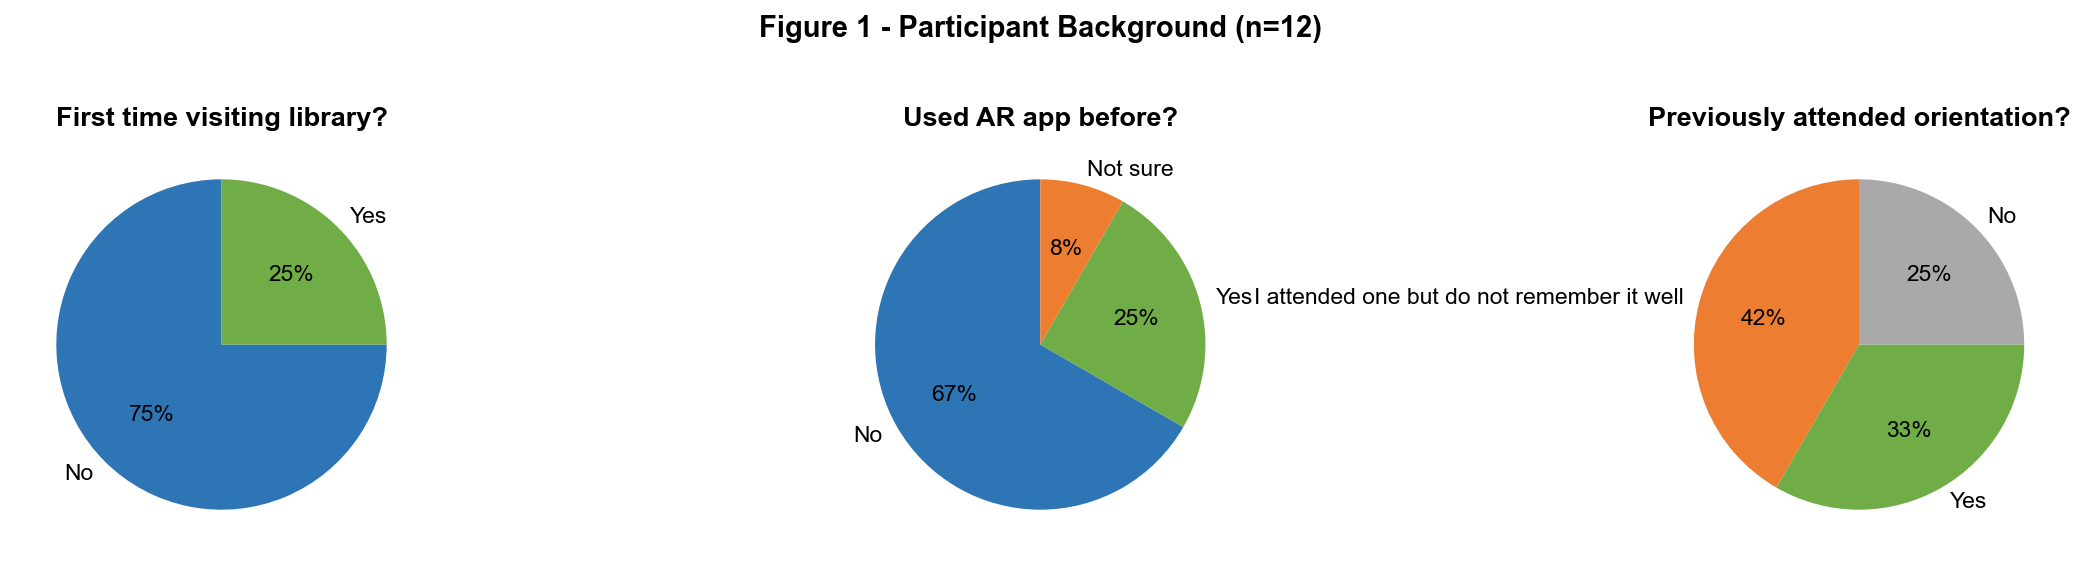

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 1 - Participant Background (n=12)', fontsize=14, fontweight='bold')
fv = df['Q1_first_visit'].value_counts()
axes[0].pie(fv.values, labels=fv.index, autopct='%1.0f%%', colors=[BLUE,GREEN], startangle=90)
axes[0].set_title('First time visiting library?')
ar = df['Q3_ar_before'].value_counts()
axes[1].pie(ar.values, labels=ar.index, autopct='%1.0f%%', colors=[BLUE,GREEN,ORANGE], startangle=90)
axes[1].set_title('Used AR app before?')
po = df['Q20_prev_orientation'].value_counts()
axes[2].pie(po.values, labels=po.index, autopct='%1.0f%%', colors=[ORANGE,GREEN,GREY], startangle=90)
axes[2].set_title('Previously attended orientation?')
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig1_participant_background.png'), bbox_inches='tight')
plt.show()

**Interpretation:** Three students (25%) were visiting the library for the first time. The majority (67%) had not used an AR application before. Notably, 50% attended a previous orientation but could not remember it well, directly supporting the literature finding that traditional orientations fail to produce lasting knowledge.

## 3. Figure 2 RQ1: Treasure Hunt Engagement

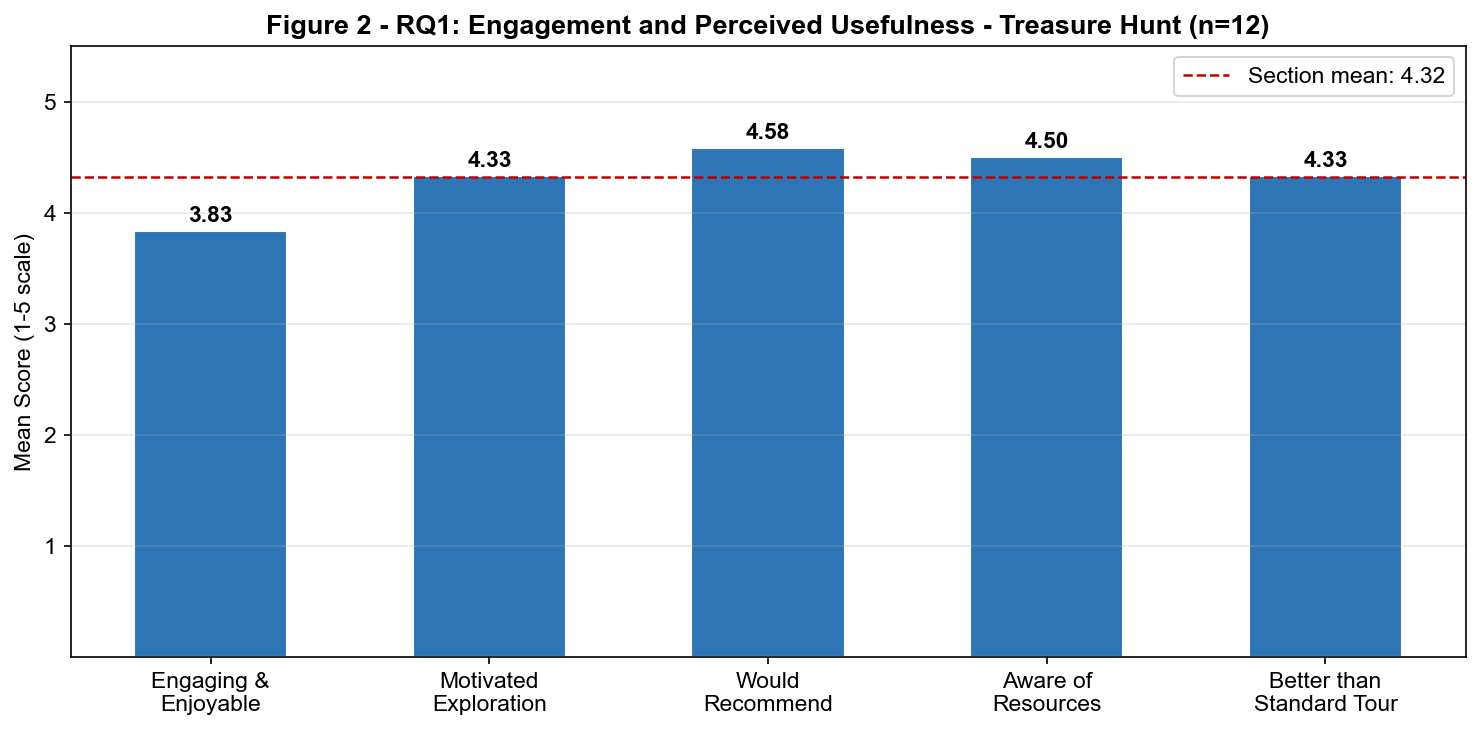

Section mean: 4.32


In [4]:
rq1_cols = ['Q4_engaging','Q5_motivated','Q7_recommend','Q8_aware','Q9_vs_tour']
rq1_labels = ['Engaging &\nEnjoyable','Motivated\nExploration','Would\nRecommend','Aware of\nResources','Better than\nStandard Tour']
rq1_means = [df[c].mean() for c in rq1_cols]
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(rq1_labels, rq1_means, color=BLUE, edgecolor='white', width=0.55)
for bar,val in zip(bars,rq1_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,5.5); ax.set_ylabel('Mean Score (1-5 scale)')
ax.set_title('Figure 2 - RQ1: Engagement and Perceived Usefulness - Treasure Hunt (n=12)')
ax.axhline(np.mean(rq1_means), color=RED, linestyle='--', linewidth=1.2, label=f'Section mean: {np.mean(rq1_means):.2f}')
ax.legend(); ax.set_yticks([1,2,3,4,5]); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig2_rq1_treasure_hunt.png'), bbox_inches='tight')
plt.show()
print(f'Section mean: {np.mean(rq1_means):.2f}')

**Interpretation:** All five RQ1 items scored above 3.80, with a section mean of 4.31 out of 5. Would Recommend scored highest (4.58). Motivated Exploration and Better than Standard Tour both scored 4.33, confirming the treasure hunt format successfully encouraged independent exploration beyond what a guided tour achieves.

## 4. Figure 3 RQ1: Book Search Usefulness

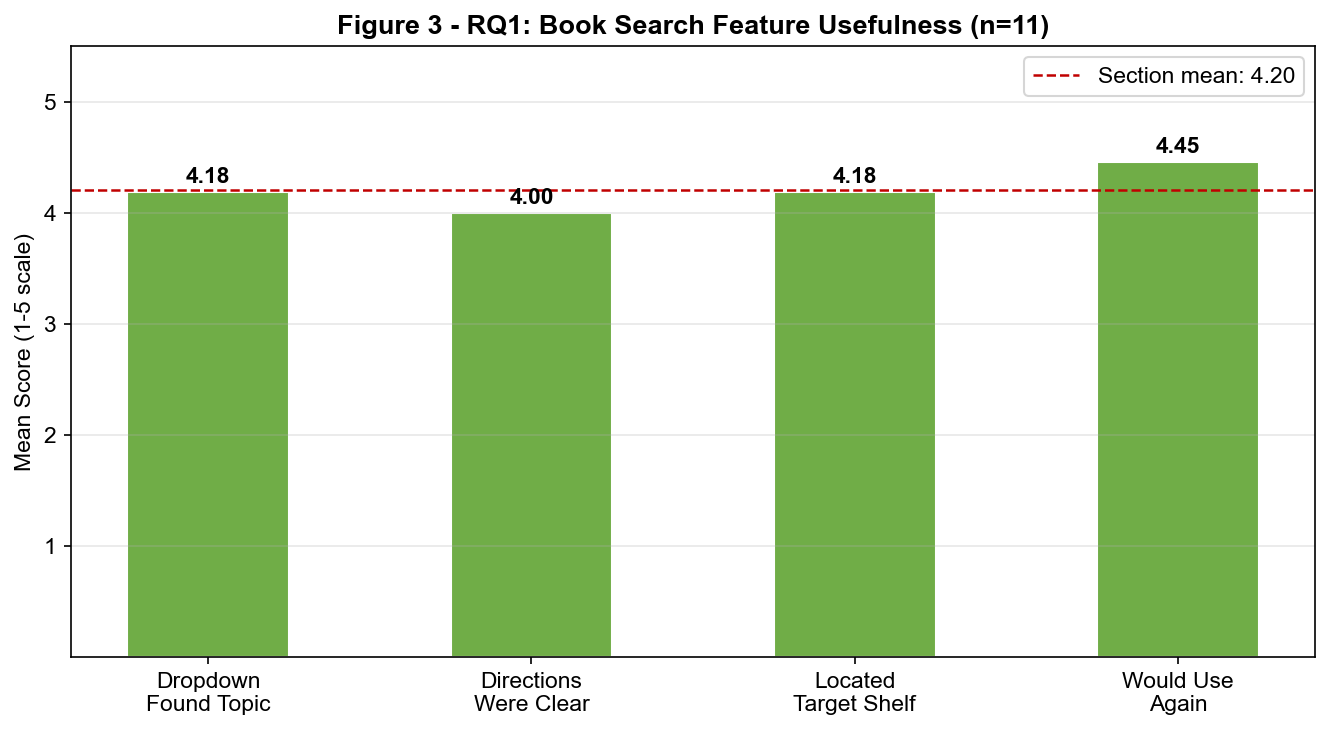

Section mean: 4.20


In [5]:
bs_cols = ['Q29_dropdown','Q30_directions','Q31_found_shelf','Q32_use_again']
bs_labels = ['Dropdown\nFound Topic','Directions\nWere Clear','Located\nTarget Shelf','Would Use\nAgain']
bs_means = [df[c].mean() for c in bs_cols]
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(bs_labels, bs_means, color=GREEN, edgecolor='white', width=0.5)
for bar,val in zip(bars,bs_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,5.5); ax.set_ylabel('Mean Score (1-5 scale)')
ax.set_title('Figure 3 - RQ1: Book Search Feature Usefulness (n=11)')
ax.axhline(np.mean(bs_means), color=RED, linestyle='--', linewidth=1.2, label=f'Section mean: {np.mean(bs_means):.2f}')
ax.legend(); ax.set_yticks([1,2,3,4,5]); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig3_rq1_book_search.png'), bbox_inches='tight')
plt.show()
print(f'Section mean: {np.mean(bs_means):.2f}')

**Interpretation:** Book Search scored a section mean of 4.20 out of 5 (n=11). Would Use Again scored highest (4.45), indicating strong future adoption intent. Directions Were Clear scored lowest (4.00), reflecting feedback from two participants who suggested more specific directional guidance.

## 5. Figure 4 RQ2: Clue Comprehension

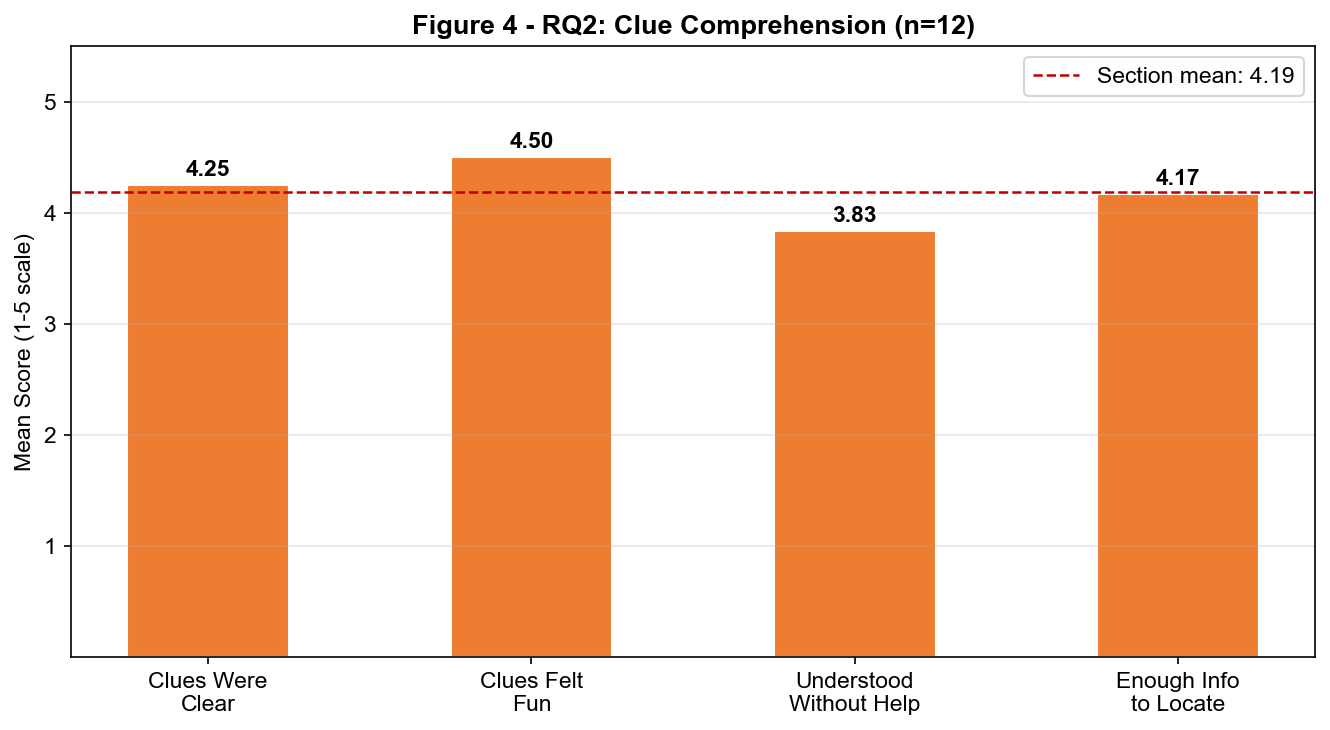

Section mean: 4.19


In [6]:
rq2_cols = ['Q13_clue_clarity','Q14_clue_fun','Q15_understood','Q16_enough_info']
rq2_labels = ['Clues Were\nClear','Clues Felt\nFun','Understood\nWithout Help','Enough Info\nto Locate']
rq2_means = [df[c].mean() for c in rq2_cols]
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(rq2_labels, rq2_means, color=ORANGE, edgecolor='white', width=0.5)
for bar,val in zip(bars,rq2_means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0,5.5); ax.set_ylabel('Mean Score (1-5 scale)')
ax.set_title('Figure 4 - RQ2: Clue Comprehension (n=12)')
ax.axhline(np.mean(rq2_means), color=RED, linestyle='--', linewidth=1.2, label=f'Section mean: {np.mean(rq2_means):.2f}')
ax.legend(); ax.set_yticks([1,2,3,4,5]); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig4_rq2_clue_comprehension.png'), bbox_inches='tight')
plt.show()
print(f'Section mean: {np.mean(rq2_means):.2f}')

**Interpretation:** Clue comprehension scored a section mean of 4.19. Clues Felt Fun scored highest (4.50), confirming LLM-generated riddle phrasing achieved its intended effect. Understood Without Help scored lowest (3.83), consistent with qualitative responses where some students needed to re-read clues before identifying the target.

## 6. Figure 5 RQ3: Confidence Before vs After

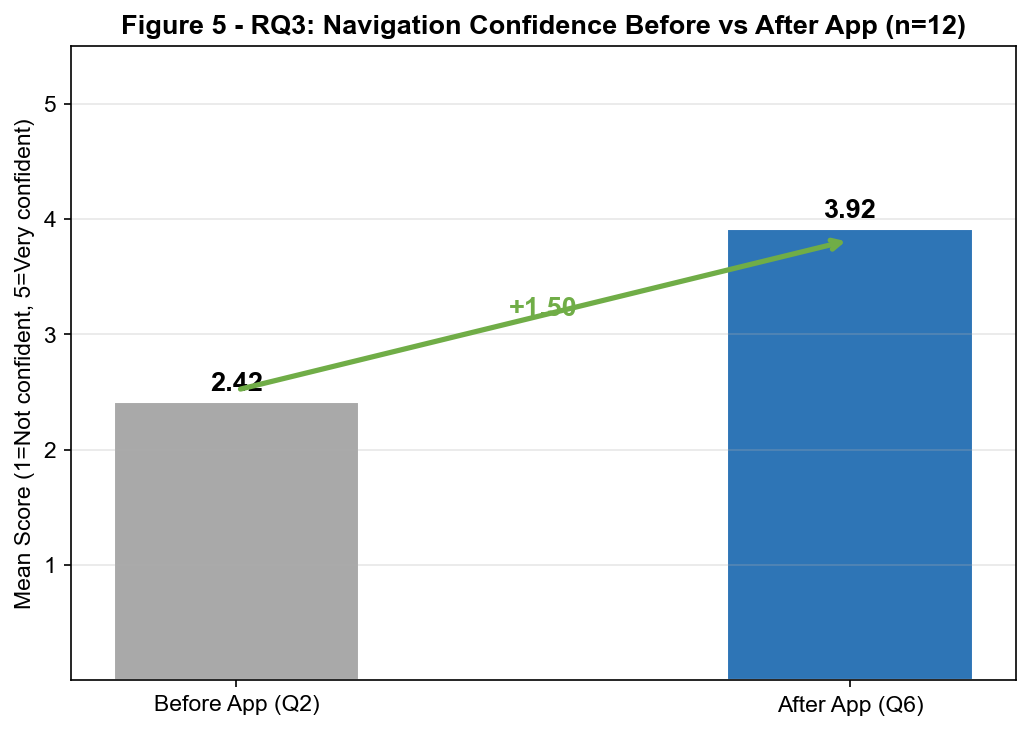

Pre: 2.42  Post: 3.92  Change: +1.50


In [7]:
pre = df['Q2_pre_conf'].mean()
post = df['Q6_confident_after'].mean()
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(['Before App (Q2)','After App (Q6)'], [pre,post], color=[GREY,BLUE], edgecolor='white', width=0.4)
for bar,val in zip(bars,[pre,post]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.annotate('', xy=(1,post-0.1), xytext=(0,pre+0.1), arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.5))
ax.text(0.5, (pre+post)/2, f'+{post-pre:.2f}', ha='center', color=GREEN, fontweight='bold', fontsize=13)
ax.set_ylim(0,5.5); ax.set_ylabel('Mean Score (1=Not confident, 5=Very confident)')
ax.set_title('Figure 5 - RQ3: Navigation Confidence Before vs After App (n=12)')
ax.set_yticks([1,2,3,4,5]); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig5_rq3_confidence.png'), bbox_inches='tight')
plt.show()
print(f'Pre: {pre:.2f}  Post: {post:.2f}  Change: +{post-pre:.2f}')

**Interpretation:** Students entered with mean confidence 2.42 out of 5. After the app, confidence rose to 3.92 - an improvement of +1.50 points (62% increase relative to baseline). This is the strongest quantitative finding in the dataset and provides direct evidence in support of RQ3.

## 7. Figure 6 RQ3: Feel More Prepared

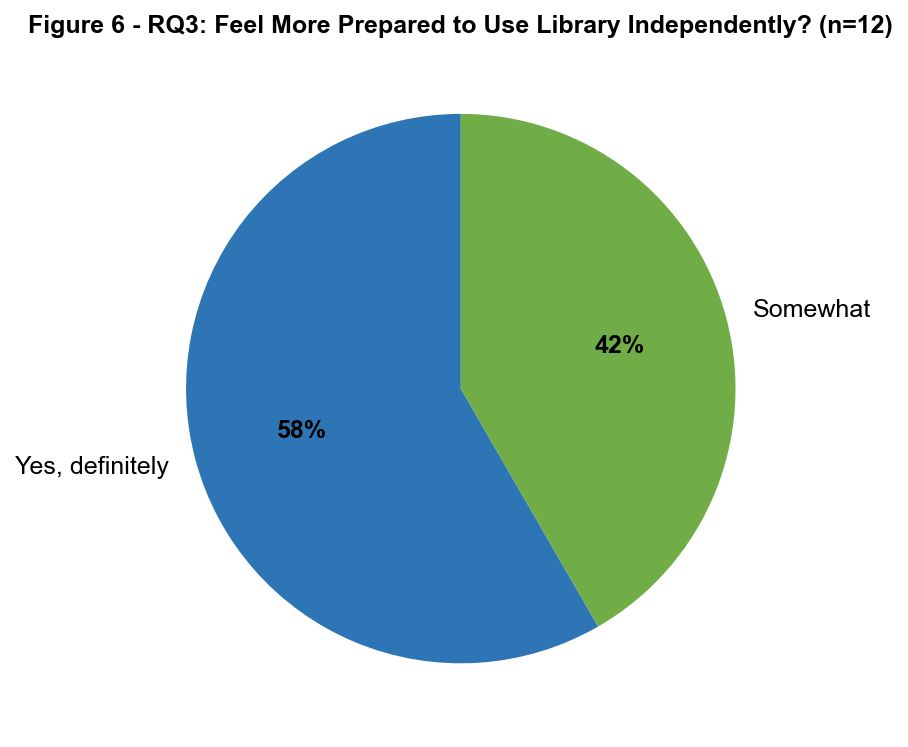

In [8]:
prepared = df['Q27_more_prepared'].value_counts()
fig, ax = plt.subplots(figsize=(6,6))
wedges,texts,autotexts = ax.pie(prepared.values, labels=prepared.index, autopct='%1.0f%%',
    colors=[BLUE,GREEN], startangle=90, textprops={'fontsize':12})
for at in autotexts: at.set_fontweight('bold')
ax.set_title('Figure 6 - RQ3: Feel More Prepared to Use Library Independently? (n=12)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig6_rq3_prepared.png'), bbox_inches='tight')
plt.show()

**Interpretation:** Every participant felt at least somewhat more prepared - 58% Yes definitely, 42% Somewhat. No student selected Not really or No. This unanimous result strongly supports RQ3 regardless of prior experience or AR familiarity.

## 8. Figure 7 RQ3: How Students Would Normally Find a Book

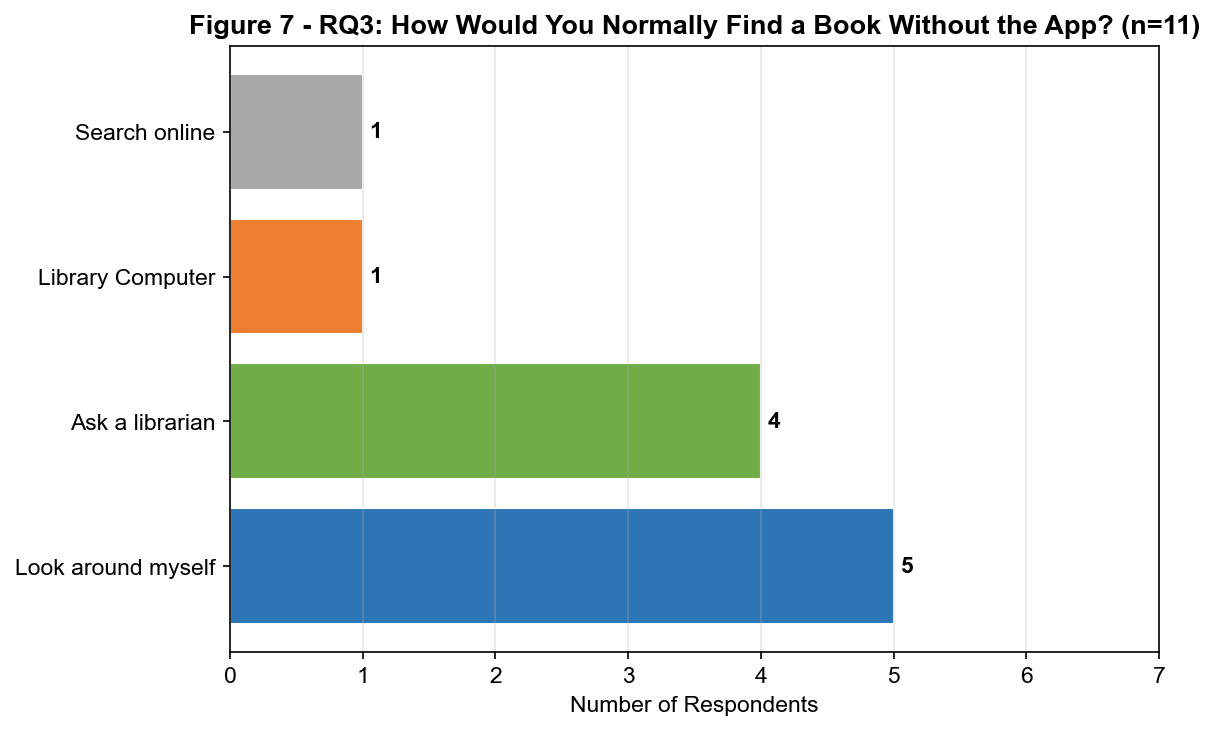

In [9]:
q33 = df['Q33_find_book'].dropna().value_counts()
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.barh(q33.index, q33.values, color=[BLUE,GREEN,ORANGE,GREY], edgecolor='white')
for bar,val in zip(bars,q33.values):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, str(val), va='center', fontweight='bold')
ax.set_xlabel('Number of Respondents')
ax.set_title('Figure 7 - RQ3: How Would You Normally Find a Book Without the App? (n=11)')
ax.set_xlim(0,7); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig7_rq3_find_book.png'), bbox_inches='tight')
plt.show()

**Interpretation:** Without the app, 45% would browse shelves themselves and 36% would ask a librarian. Only 18% would use a systematic method. This confirms most students lack a structured book-finding approach, highlighting the value of Book Search as a self-service alternative.

## 9. Figure 8 Overall App Rating

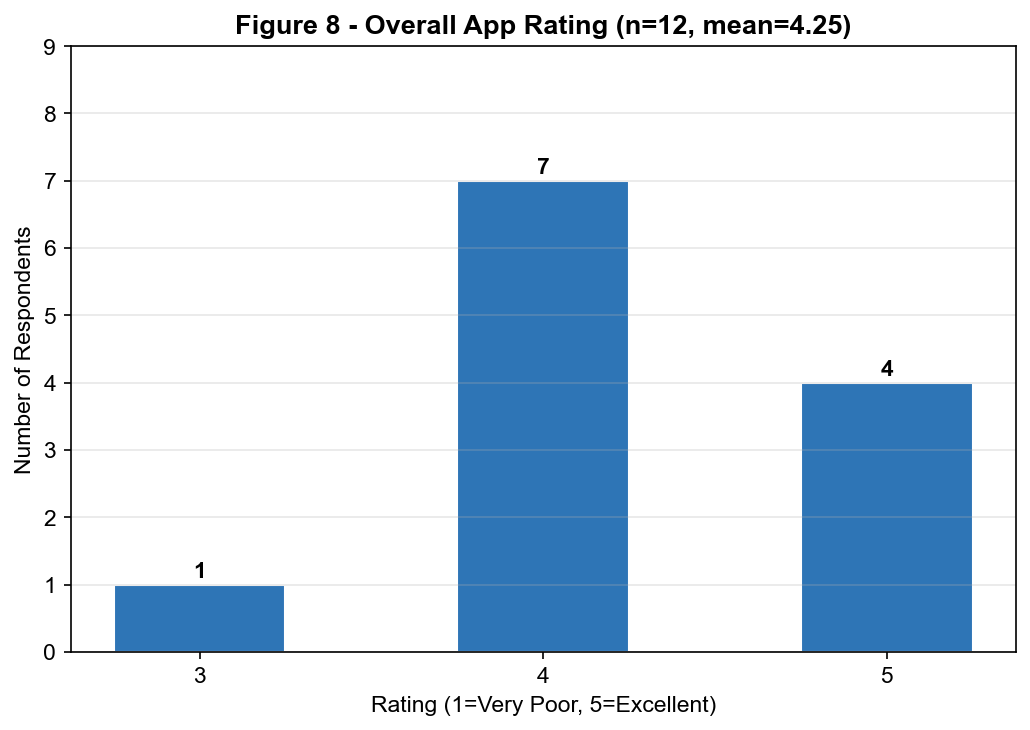

Q26_overall
3    1
4    7
5    4
Name: count, dtype: int64


In [10]:
overall = df['Q26_overall'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(overall.index.astype(str), overall.values, color=BLUE, edgecolor='white', width=0.5)
for bar,val in zip(bars,overall.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, str(val), ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Rating (1=Very Poor, 5=Excellent)'); ax.set_ylabel('Number of Respondents')
ax.set_title(f'Figure 8 - Overall App Rating (n=12, mean={df["Q26_overall"].mean():.2f})')
ax.set_ylim(0,overall.max()+2); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig8_overall_rating.png'), bbox_inches='tight')
plt.show()
print(overall)

**Interpretation:** Overall rating mean was 4.25 out of 5. Eight of twelve students (67%) rated the app 4 or 5. One student rated all items at 3 (neutral). No student awarded a rating below 3, confirming no participant had a negative overall experience.

## 10. Load App Session Logs

In [11]:
log_dir = r'C:\Users\chrwr\Desktop\ARLibNav_EvaluationLogs'
sessions = {}
for f in glob.glob(os.path.join(log_dir, '*.csv')):
    with open(f, encoding='utf-8') as fh:
        rows = list(csv.DictReader(fh))
    if rows: sessions[rows[0]['session_id']] = rows

def parse_ts(ts): return datetime.strptime(ts, '%Y-%m-%dT%H:%M:%S.%fZ')

hunt_sessions = {s:r for s,r in sessions.items() if any(x['event_type']=='TREASURE_HUNT_START' for x in r)}
print(f'Total sessions: {len(sessions)} | Hunt sessions: {len(hunt_sessions)}')

Total sessions: 30 | Hunt sessions: 15


## 11. Figure 9 Per Clue Time and Scan Attempts

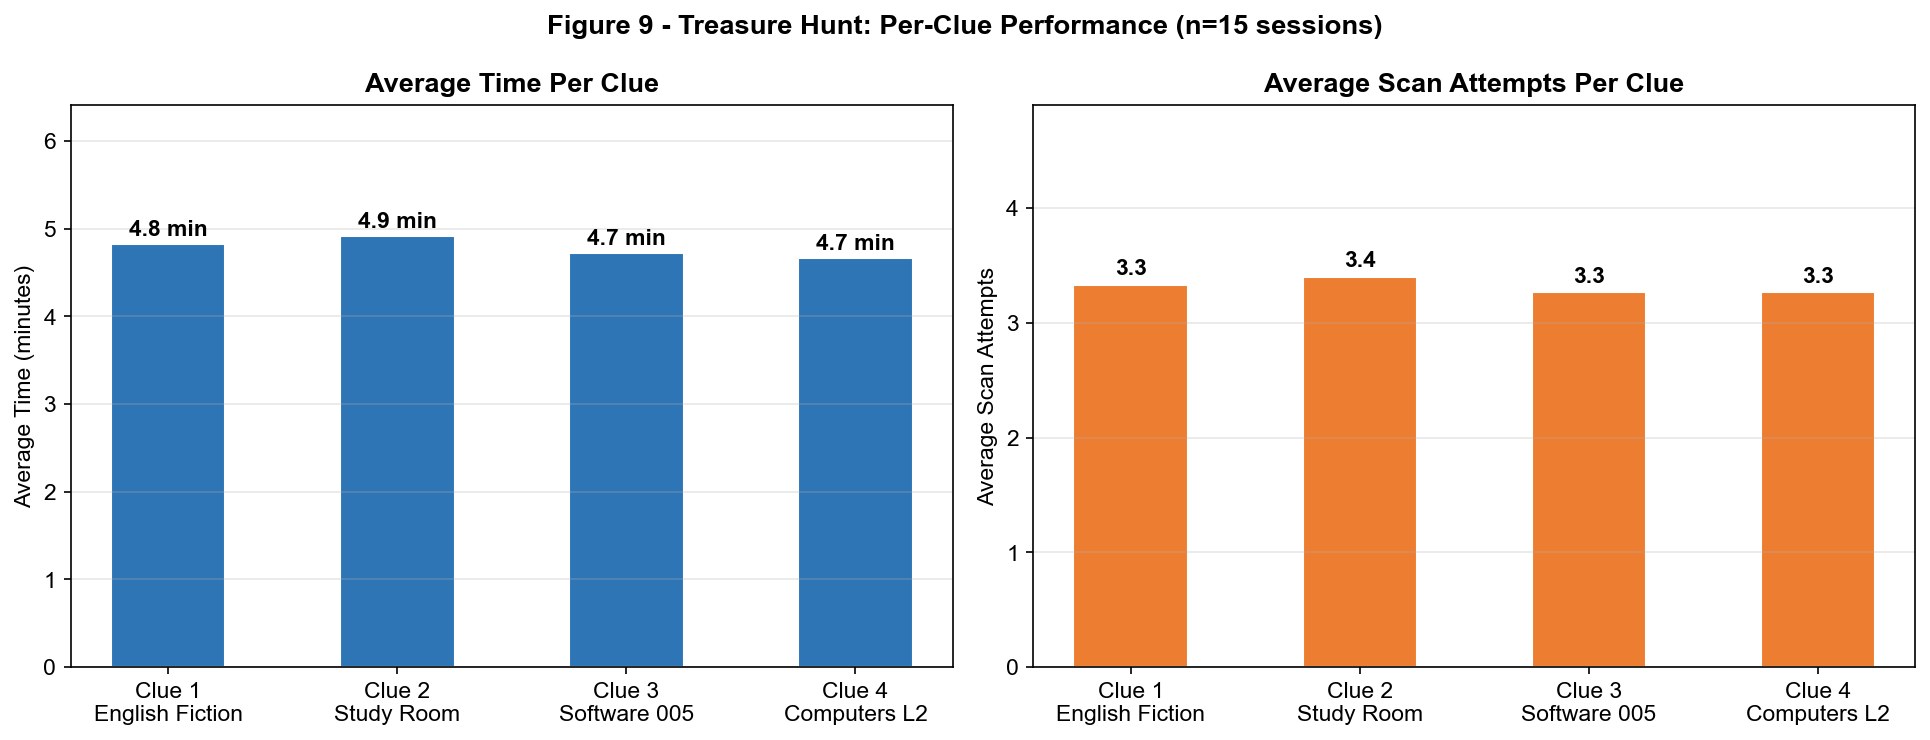

Avg hunt time: 19.2 min  Min: 9.7  Max: 31.2


In [12]:
hunt_totals=[]
clue_times={0:[],1:[],2:[],3:[]}; clue_scans={0:[],1:[],2:[],3:[]}; clue_rejects={0:[],1:[],2:[],3:[]}

for sid,rows in hunt_sessions.items():
    start=next((r for r in rows if r['event_type']=='TREASURE_HUNT_START'),None)
    end=next((r for r in rows if r['event_type']=='TREASURE_HUNT_COMPLETE'),None)
    if start and end: hunt_totals.append((parse_ts(end['timestamp'])-parse_ts(start['timestamp'])).total_seconds())
    shown,confirmed,sc,rj={},{},{0:0,1:0,2:0,3:0},{0:0,1:0,2:0,3:0}
    for r in rows:
        et,d,ts=r['event_type'],r['data'],parse_ts(r['timestamp'])
        if et=='CLUE_SHOWN': shown[int(d.split('index=')[1].split(' ')[0])]=ts
        elif et=='CLUE_CONFIRMED': confirmed[int(d.split('index=')[1].split(' ')[0])]=ts
        elif et=='SCAN_ATTEMPT': sc[int(d.split('clue=')[1].split(' ')[0])]+=1
        elif et=='SCAN_REJECTED' and 'clue=' in d: rj[int(d.split('clue=')[1].split(' ')[0])]+=1
    for i in range(4):
        if i in shown and i in confirmed: clue_times[i].append((confirmed[i]-shown[i]).total_seconds())
        clue_scans[i].append(sc[i]); clue_rejects[i].append(rj[i])

clue_names=['Clue 1\nEnglish Fiction','Clue 2\nStudy Room','Clue 3\nSoftware 005','Clue 4\nComputers L2']
avg_times=[np.mean(clue_times[i])/60 for i in range(4)]
avg_scans=[np.mean(clue_scans[i]) for i in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Figure 9 - Treasure Hunt: Per-Clue Performance (n=15 sessions)', fontweight='bold')
bars1=axes[0].bar(clue_names, avg_times, color=BLUE, edgecolor='white', width=0.5)
for bar,val in zip(bars1,avg_times): axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,f'{val:.1f} min',ha='center',va='bottom',fontweight='bold')
axes[0].set_ylabel('Average Time (minutes)'); axes[0].set_title('Average Time Per Clue')
axes[0].set_ylim(0,max(avg_times)+1.5); axes[0].grid(axis='y',alpha=0.3)
bars2=axes[1].bar(clue_names, avg_scans, color=ORANGE, edgecolor='white', width=0.5)
for bar,val in zip(bars2,avg_scans): axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,f'{val:.1f}',ha='center',va='bottom',fontweight='bold')
axes[1].set_ylabel('Average Scan Attempts'); axes[1].set_title('Average Scan Attempts Per Clue')
axes[1].set_ylim(0,max(avg_scans)+1.5); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig9_clue_performance.png'), bbox_inches='tight')
plt.show()
print(f'Avg hunt time: {np.mean(hunt_totals)/60:.1f} min  Min: {min(hunt_totals)/60:.1f}  Max: {max(hunt_totals)/60:.1f}')

**Interpretation:** Average time per clue ranged from 4.7 to 4.9 minutes with balanced difficulty across all four clues. Total hunt time averaged 19.2 minutes (range 9.7-31.2 min). All clues required approximately 3.3 scan attempts on average, indicating difficulty was driven by the scanning mechanism rather than clue wording or location difficulty.

## 12. Figure 10 Gemini Vision Rejection Rate

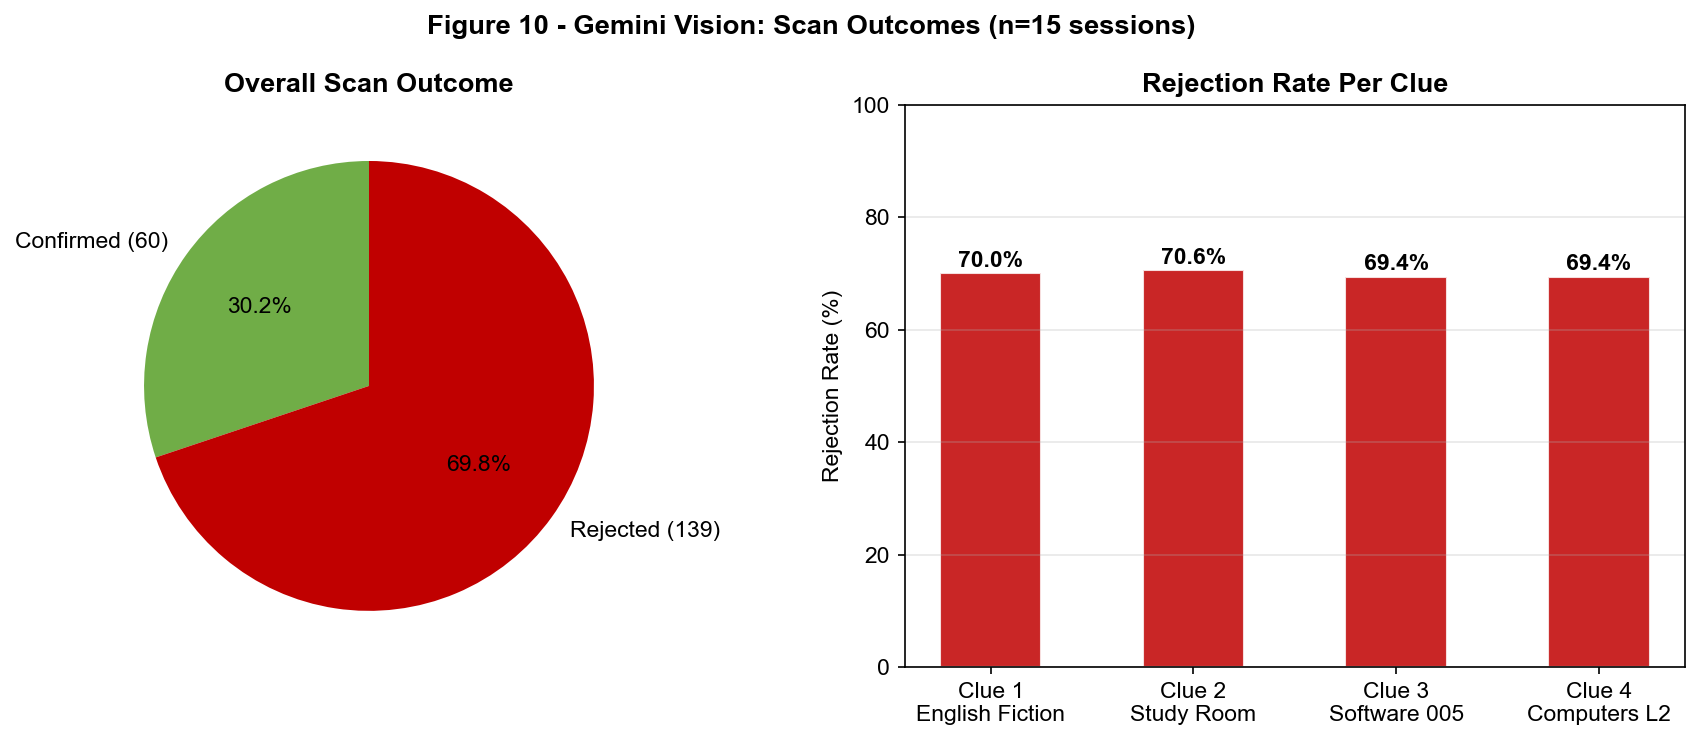

Attempts: 199 | Confirmed: 60 | Rejected: 139 | Rate: 69.8%


In [13]:
total_attempts=sum(sum(clue_scans[i]) for i in range(4))
total_rejects=sum(sum(clue_rejects[i]) for i in range(4))
total_confirms=total_attempts-total_rejects

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Figure 10 - Gemini Vision: Scan Outcomes (n=15 sessions)', fontweight='bold')
axes[0].pie([total_confirms,total_rejects],
    labels=[f'Confirmed ({total_confirms})',f'Rejected ({total_rejects})'],
    autopct='%1.1f%%',colors=[GREEN,RED],startangle=90)
axes[0].set_title('Overall Scan Outcome')
per_clue_rej=[sum(clue_rejects[i])/sum(clue_scans[i])*100 if sum(clue_scans[i])>0 else 0 for i in range(4)]
bars=axes[1].bar(clue_names,per_clue_rej,color=RED,edgecolor='white',width=0.5,alpha=0.85)
for bar,val in zip(bars,per_clue_rej): axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val:.1f}%',ha='center',va='bottom',fontweight='bold')
axes[1].set_ylabel('Rejection Rate (%)'); axes[1].set_title('Rejection Rate Per Clue')
axes[1].set_ylim(0,100); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'fig10_scan_rejection.png'), bbox_inches='tight')
plt.show()
print(f'Attempts: {total_attempts} | Confirmed: {total_confirms} | Rejected: {total_rejects} | Rate: {total_rejects/total_attempts*100:.1f}%')

**Interpretation:** Overall Gemini Vision rejection rate was 69.8% across 199 scan attempts. While high, this reflects real-world conditions including variable lighting and camera angle variation. Critically, all 15 participants received confirmation for every clue - the system was functional despite the friction. This is the primary technical limitation identified in the study.

## 13. Summary Table All Question Means

In [14]:
summary = pd.DataFrame({
    'Section': ['RQ1 Treasure Hunt']*5 + ['RQ1 Book Search']*4 + ['RQ2 Clue Comprehension']*4 + ['RQ3 Confidence']*2 + ['Overall'],
    'Question': ['Engaging (Q4)','Motivated (Q5)','Recommend (Q7)','Aware (Q8)','vs Tour (Q9)',
                 'Dropdown (Q29)','Directions (Q30)','Found Shelf (Q31)','Use Again (Q32)',
                 'Clue Clear (Q13)','Clue Fun (Q14)','Understood (Q15)','Enough Info (Q16)',
                 'Pre-Confidence (Q2)','Post-Confidence (Q6)','Overall Rating (Q26)'],
    'Mean (/5)': [3.83,4.33,4.58,4.50,4.33,4.18,4.00,4.18,4.45,4.25,4.50,3.83,4.17,2.42,3.92,4.25]
})
print(summary.to_string(index=False))
summary.to_excel(os.path.join(OUT,'summary_table.xlsx'), index=False)
print(f'\nAll 10 charts saved to: {OUT}')

               Section             Question  Mean (/5)
     RQ1 Treasure Hunt        Engaging (Q4)       3.83
     RQ1 Treasure Hunt       Motivated (Q5)       4.33
     RQ1 Treasure Hunt       Recommend (Q7)       4.58
     RQ1 Treasure Hunt           Aware (Q8)       4.50
     RQ1 Treasure Hunt         vs Tour (Q9)       4.33
       RQ1 Book Search       Dropdown (Q29)       4.18
       RQ1 Book Search     Directions (Q30)       4.00
       RQ1 Book Search    Found Shelf (Q31)       4.18
       RQ1 Book Search      Use Again (Q32)       4.45
RQ2 Clue Comprehension     Clue Clear (Q13)       4.25
RQ2 Clue Comprehension       Clue Fun (Q14)       4.50
RQ2 Clue Comprehension     Understood (Q15)       3.83
RQ2 Clue Comprehension    Enough Info (Q16)       4.17
        RQ3 Confidence  Pre-Confidence (Q2)       2.42
        RQ3 Confidence Post-Confidence (Q6)       3.92
               Overall Overall Rating (Q26)       4.25

All 10 charts saved to: C:\Users\chrwr\Documents\mcast\3rd year\